## EX 1:  Mass-spring damper system


Let us consider a mass-spring-damper system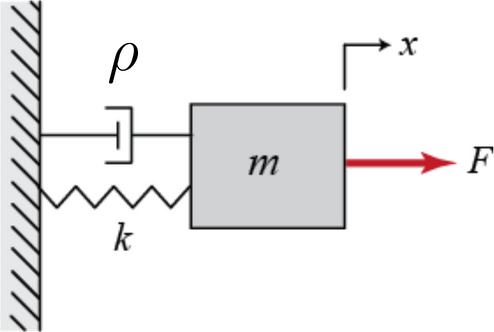

With the following system parameters:

      mass  m = 1.0 kg

      spring constant k = 5.0 N/m

      damping constant $\rho$ = 2 Ns/m

The state space model of the system is the following:

$$\dot x = Ax + Bu$$
$$ y = Cx$$

where
state vector $x = (p,v)$ (p - position, v - velocity), and state and control matrices are the following:
$$ A = \begin{pmatrix} 0&1\\ -\frac{k}{m}&-\frac{\rho}{m}\end{pmatrix},\ B = \begin{pmatrix} 0\\ \frac{1}{m} 
\end{pmatrix}$$

## TODO
1. Is the system controllable?

Answer:

Yes, the system is controllable. The controllability matrix is $\mathcal{C} = [B\ AB] = \begin{pmatrix}0 & \frac{1}{m}\\ \frac{1}{m} & -\frac{\rho}{m^2}\end{pmatrix}$. Its determinant is $-\frac{1}{m^2}$, which is nonzero for $m=1$. Therefore, the matrix has rank 2 and the two states can be controlled by the input.

2. Design a PID controller that ensures that the position of the closed-loop system tracks the constant reference $y_{ref}(t) = 1.$ Plot the trajectory of the closed-loop system, starting from $x = (0,0).$ Tune PID to ensure that rising time < 10s, overshoot < 10%, Steady-state error < 2%.  
3. Design a full-state feedback controller with an integral term $u = -Kx + k_z\int_0^t(y_{ref}(\tau) - p(\tau))\,d\tau$ that ensures that the position of the closed-loop system tracks the constant reference $y_{ref}(t) = 1.$  Plot the trajectory of the closed-loop system, starting from $x = (0,0).$ Chose eigenvalues properly, to ensure that rising time < 10s, overshoot < 10%, Steady-state error < 2%.  
4. Compare the performance of PID and full-state feedback controllers. What can you say? 

Let us now work with a discretized version of the system.

5. Disretise the system with sampling time T = 0.1s
6. Design a discrete version of the PID controller that ensures that the position of the closed-loop system tracks the constant reference $y_{ref,k} = 1.$ Plot the trajectory of the closed-loop system, starting from $x = (0,0).$ Tune PID to ensure that rising time < 10s, overshoot < 10%, Steady-state error < 2%.  
7. Design a full-state feedback controller with an integral term $u_k = - Kx_k + k_z\sum_{i=0}^k(y_{ref, i} - p_i)$ that ensures that the position of the closed-loop system tracks the constant reference $y_{ref,k} = 1.$  Plot the trajectory of the closed-loop system, starting from $x = (0,0).$ Chose eigenvalues properly to ensure that rising time < 10s, overshoot < 10%, Steady-state error < 2%.  
8. Compare the performance of PID and full-state feedback controllers. What can you say?


### Answer TODO 2

A PID controller with gains $K_p = 15$, $K_i = 3$ and $K_d = 4$ was used. With this tuning, the closed-loop system tracks the reference $y_{ref}(t)=1$ from $x=(0,0)$. The overshoot is $0\%$, so this condition is satisfied. The rise time is about $5.15\,s$, which means the output reaches $90\%$ of the reference in less than $10\,s$. The tracking error at $t = 25\,s$ is about $0.44\%$. Because the controller has an integral action, the steady-state error for a constant reference should converge to zero. The code and plots are shown below.

Kp = 15.0, Ki = 3.0, Kd = 4.0
Rise time: 5.15 s
Overshoot: 0.00 %
Steady-state error: 0.44 %


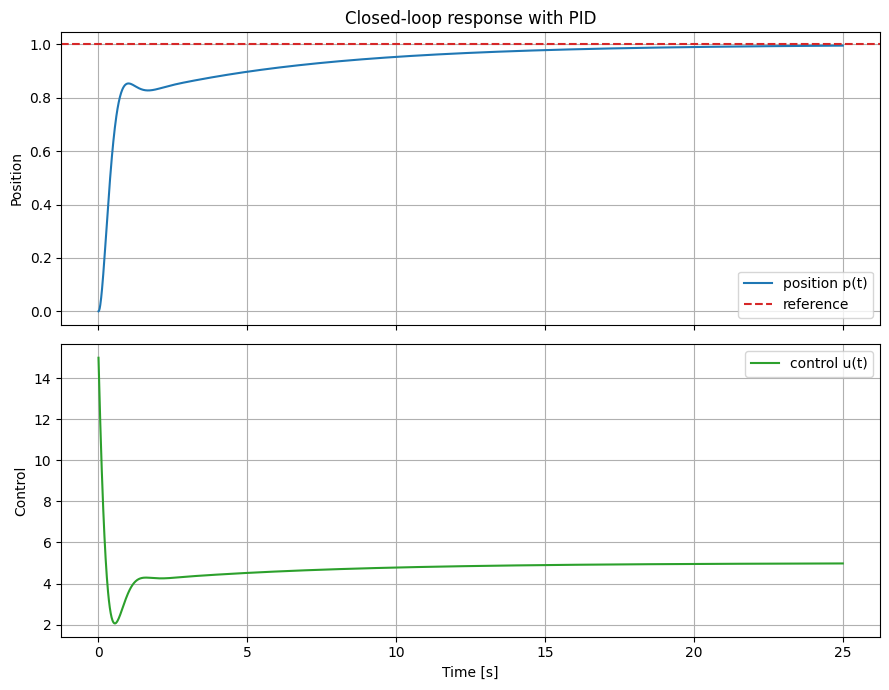

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

m = 1.0
k = 5.0
rho = 2.0

Kp = 15.0
Ki = 3.0
Kd = 4.0
y_ref = 1.0

def closed_loop_pid(t, z):
    p, v, integral_error = z
    error = y_ref - p
    u = Kp * error + Ki * integral_error - Kd * v
    dp = v
    dv = -(k / m) * p - (rho / m) * v + u / m
    dintegral_error = error
    return [dp, dv, dintegral_error]

t_eval = np.linspace(0.0, 25.0, 2501)
z0 = [0.0, 0.0, 0.0]

solution = solve_ivp(
    closed_loop_pid,
    [t_eval[0], t_eval[-1]],
    z0,
    t_eval=t_eval,
    max_step=0.02,
    rtol=1e-8,
    atol=1e-8,
 )

t = solution.t
p = solution.y[0]
v = solution.y[1]
integral_error = solution.y[2]
u = Kp * (y_ref - p) + Ki * integral_error - Kd * v

peak_value = np.max(p)
overshoot = max(0.0, (peak_value - y_ref) / y_ref * 100.0)
rise_index = np.where(p >= 0.9 * y_ref)[0]
rise_time = t[rise_index[0]] if len(rise_index) > 0 else np.nan
steady_state_error = abs(y_ref - p[-1]) / y_ref * 100.0

print(f"Kp = {Kp}, Ki = {Ki}, Kd = {Kd}")
print(f"Rise time: {rise_time:.2f} s")
print(f"Overshoot: {overshoot:.2f} %")
print(f"Steady-state error: {steady_state_error:.2f} %")

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

axes[0].plot(t, p, label="position p(t)", color="tab:blue")
axes[0].axhline(y_ref, color="tab:red", linestyle="--", label="reference")
axes[0].set_ylabel("Position")
axes[0].set_title("Closed-loop response with PID")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(t, u, label="control u(t)", color="tab:green")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Control")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

### Answer TODO 3

A full-state feedback controller with integral action was designed using pole placement for the augmented system. The poles were chosen at $-1$, $-1.5$ and $-2$, which gives $K = [1.5, 2.5]$ and $k_z = 3$. With this choice, the closed-loop system tracks the reference from $x=(0,0)$ with rise time about $3.90\,s$, overshoot $0\%$, and practically zero steady-state error. The code and plots are shown below.

Chosen poles: [-1.0, -1.5, -2.0]
K = [1.50, 2.50]
k_z = 3.00
Rise time: 3.90 s
Overshoot: 0.00 %
Steady-state error: 8.33e-09 %


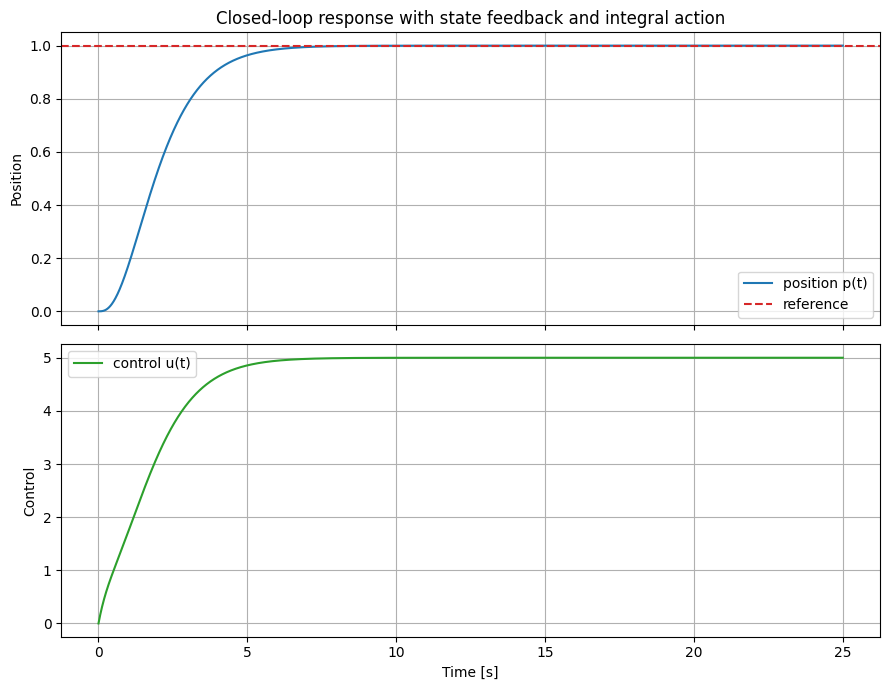

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import place_poles

m = 1.0
k = 5.0
rho = 2.0
y_ref = 1.0

A = np.array([[0.0, 1.0], [-k / m, -rho / m]])
B = np.array([[0.0], [1.0 / m]])
C = np.array([[1.0, 0.0]])

A_aug = np.block([
    [A, np.zeros((2, 1))],
    [-C, np.zeros((1, 1))],
])
B_aug = np.vstack([B, [[0.0]]])

desired_poles = [-1.0, -1.5, -2.0]
K_aug = place_poles(A_aug, B_aug, desired_poles).gain_matrix[0]
K = K_aug[:2]
k_z = -K_aug[2]

def closed_loop_state_feedback(t, z):
    p, v, integral_error = z
    x = np.array([p, v])
    u = -K @ x + k_z * integral_error
    dp = v
    dv = -(k / m) * p - (rho / m) * v + u / m
    dintegral_error = y_ref - p
    return [dp, dv, dintegral_error]

t_eval = np.linspace(0.0, 25.0, 2501)
z0 = [0.0, 0.0, 0.0]

solution_sf = solve_ivp(
    closed_loop_state_feedback,
    [t_eval[0], t_eval[-1]],
    z0,
    t_eval=t_eval,
    max_step=0.02,
    rtol=1e-8,
    atol=1e-8,
 )

t_sf = solution_sf.t
p_sf = solution_sf.y[0]
v_sf = solution_sf.y[1]
integral_error_sf = solution_sf.y[2]
u_sf = -K[0] * p_sf - K[1] * v_sf + k_z * integral_error_sf

peak_value_sf = np.max(p_sf)
overshoot_sf = max(0.0, (peak_value_sf - y_ref) / y_ref * 100.0)
rise_index_sf = np.where(p_sf >= 0.9 * y_ref)[0]
rise_time_sf = t_sf[rise_index_sf[0]] if len(rise_index_sf) > 0 else np.nan
steady_state_error_sf = abs(y_ref - p_sf[-1]) / y_ref * 100.0

print(f"Chosen poles: {desired_poles}")
print(f"K = [{K[0]:.2f}, {K[1]:.2f}]")
print(f"k_z = {k_z:.2f}")
print(f"Rise time: {rise_time_sf:.2f} s")
print(f"Overshoot: {overshoot_sf:.2f} %")
print(f"Steady-state error: {steady_state_error_sf:.2e} %")

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

axes[0].plot(t_sf, p_sf, label="position p(t)", color="tab:blue")
axes[0].axhline(y_ref, color="tab:red", linestyle="--", label="reference")
axes[0].set_ylabel("Position")
axes[0].set_title("Closed-loop response with state feedback and integral action")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(t_sf, u_sf, label="control u(t)", color="tab:green")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Control")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

### Answer TODO 4

Both controllers satisfy the requested conditions, since both have overshoot below $10\%$, rise time below $10\,s$, and steady-state error below $2\%$. In this case, the full-state feedback with integral action gives better performance, because it is faster than the PID controller and its steady-state error is practically zero. The PID controller also works well, but it is a little slower and keeps a small residual error at the end.

### Answer TODO 5

Using zero-order hold with sampling time $T = 0.1\,s$, the continuous-time model is discretized as
$$x_{k+1} = A_d x_k + B_d u_k, \quad y_k = C_d x_k + D_d u_k.$$
For this system, the discrete matrices are
$$A_d = \begin{pmatrix}0.97668263 & 0.08988172\\ -0.44940861 & 0.79691919\end{pmatrix}, \quad B_d = \begin{pmatrix}0.00466347\\ 0.08988172\end{pmatrix}.$$
Also, $C_d = C = \begin{pmatrix}1 & 0\end{pmatrix}$ and $D_d = 0$. The code used to compute these matrices is shown below.

In [3]:
import numpy as np
from scipy.signal import cont2discrete

m = 1.0
k = 5.0
rho = 2.0
T = 0.1

A = np.array([[0.0, 1.0], [-k / m, -rho / m]])
B = np.array([[0.0], [1.0 / m]])
C = np.array([[1.0, 0.0]])
D = np.array([[0.0]])

A_d, B_d, C_d, D_d, dt = cont2discrete((A, B, C, D), T, method="zoh")

print("A_d =")
print(A_d)
print()
print("B_d =")
print(B_d)
print()
print("C_d =")
print(C_d)
print()
print("D_d =")
print(D_d)
print()
print(f"Sampling time: {dt}")

A_d =
[[ 0.97668263  0.08988172]
 [-0.44940861  0.79691919]]

B_d =
[[0.00466347]
 [0.08988172]]

C_d =
[[1. 0.]]

D_d =
[[0.]]

Sampling time: 0.1


### Answer TODO 6

A discrete PID controller was designed for the discretized model with sampling time $T = 0.1\,s$. A good tuning is $K_p = 8$, $K_i = 5$, and $K_d = 1$. With this choice, the output tracks the constant reference $y_{ref,k} = 1$ from $x=(0,0)$ with overshoot $0\%$, rise time about $0.8\,s$, and tracking error at the end of the simulation about $0.001\%$. Because the controller has an integral action, the tracking error for a constant reference should converge to zero. The code and plots are shown below.

Kp = 8.0, Ki = 5.0, Kd = 1.0
Rise time: 0.80 s
Overshoot: 0.00 %
Tracking error at t = 24.9 s: 0.001 %


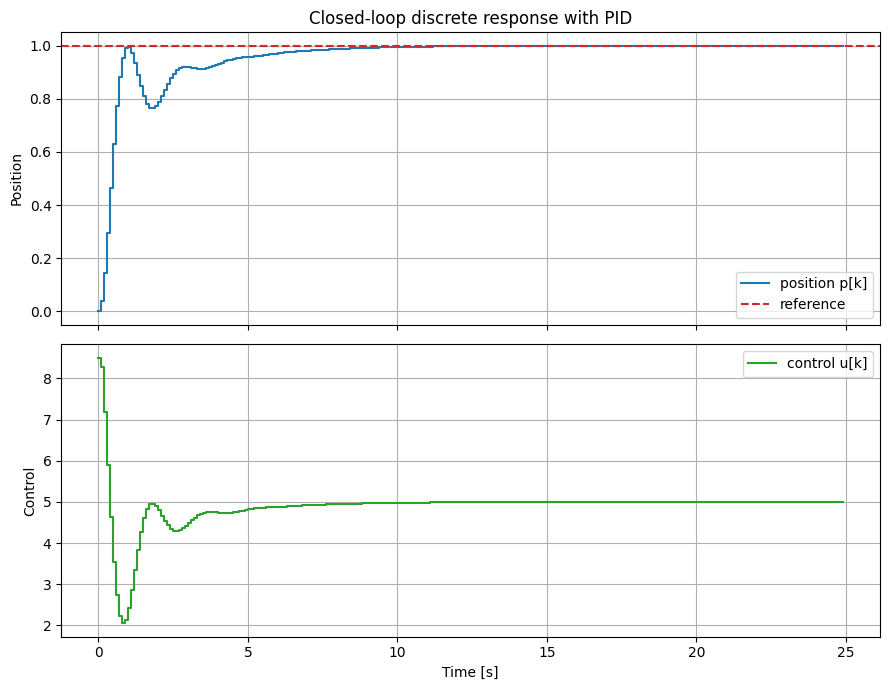

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import cont2discrete

m = 1.0
k = 5.0
rho = 2.0
T = 0.1
y_ref = 1.0

A = np.array([[0.0, 1.0], [-k / m, -rho / m]])
B = np.array([[0.0], [1.0 / m]])
C = np.array([[1.0, 0.0]])
D = np.array([[0.0]])

A_d, B_d, C_d, D_d, dt = cont2discrete((A, B, C, D), T, method="zoh")

Kp_d = 8.0
Ki_d = 5.0
Kd_d = 1.0

n_steps = 250
x = np.zeros(2)
e_prev = y_ref
integral_error_d = 0.0

time = np.arange(n_steps) * T
position_d = np.zeros(n_steps)
control_d = np.zeros(n_steps)

for i in range(n_steps):
    y = x[0]
    error = y_ref - y
    integral_error_d += error * T
    derivative_error = 0.0 if i == 0 else (error - e_prev) / T
    u = Kp_d * error + Ki_d * integral_error_d + Kd_d * derivative_error

    position_d[i] = y
    control_d[i] = u

    x = A_d @ x + B_d.flatten() * u
    e_prev = error

peak_value_d = np.max(position_d)
overshoot_d = max(0.0, (peak_value_d - y_ref) / y_ref * 100.0)
rise_index_d = np.where(position_d >= 0.9 * y_ref)[0]
rise_time_d = time[rise_index_d[0]] if len(rise_index_d) > 0 else np.nan
tracking_error_d = abs(y_ref - position_d[-1]) / y_ref * 100.0

print(f"Kp = {Kp_d}, Ki = {Ki_d}, Kd = {Kd_d}")
print(f"Rise time: {rise_time_d:.2f} s")
print(f"Overshoot: {overshoot_d:.2f} %")
print(f"Tracking error at t = {time[-1]:.1f} s: {tracking_error_d:.3f} %")

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

axes[0].step(time, position_d, where="post", label="position p[k]", color="tab:blue")
axes[0].axhline(y_ref, color="tab:red", linestyle="--", label="reference")
axes[0].set_ylabel("Position")
axes[0].set_title("Closed-loop discrete response with PID")
axes[0].grid(True)
axes[0].legend()

axes[1].step(time, control_d, where="post", label="control u[k]", color="tab:green")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Control")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

### Answer TODO 7

A discrete full-state feedback controller with integral action was designed for the discretized model with sampling time $T = 0.1\,s$. The poles of the augmented closed-loop system were chosen at $0.7$, $0.75$, and $0.8$. This gives $K = [14.64, 5.07]$ and $k_z = 1.66$. With this choice, the output tracks the constant reference $y_{ref,k} = 1$ from $x=(0,0)$ with overshoot $0\%$, rise time about $2.0\,s$, and tracking error at the end of the simulation practically equal to zero. The code and plots are shown below.

Chosen poles: [0.7, 0.75, 0.8]
K = [14.64, 5.07]
k_z = 1.66
Rise time: 2.00 s
Overshoot: 0.00 %
Tracking error at t = 24.9 s: 1.11e-14 %


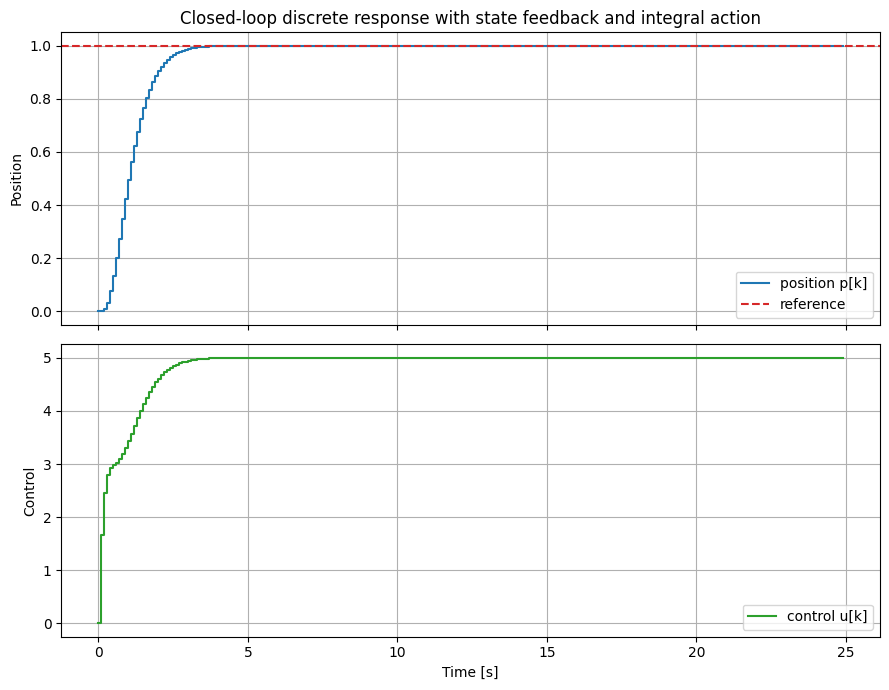

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import cont2discrete, place_poles

m = 1.0
k = 5.0
rho = 2.0
T = 0.1
y_ref = 1.0

A = np.array([[0.0, 1.0], [-k / m, -rho / m]])
B = np.array([[0.0], [1.0 / m]])
C = np.array([[1.0, 0.0]])
D = np.array([[0.0]])

A_d, B_d, C_d, D_d, dt = cont2discrete((A, B, C, D), T, method="zoh")

A_aug_d = np.block([
    [A_d, np.zeros((2, 1))],
    [-C_d, np.array([[1.0]])],
])
B_aug_d = np.vstack([B_d, [[0.0]]])

desired_poles_d = [0.7, 0.75, 0.8]
K_aug_d = place_poles(A_aug_d, B_aug_d, desired_poles_d).gain_matrix[0]
K_d = K_aug_d[:2]
k_z_d = -K_aug_d[2]

n_steps = 250
x = np.zeros(2)
integral_error_sf_d = 0.0

time = np.arange(n_steps) * T
position_sf_d = np.zeros(n_steps)
control_sf_d = np.zeros(n_steps)

for i in range(n_steps):
    y = x[0]
    error = y_ref - y
    u = -K_d @ x + k_z_d * integral_error_sf_d

    position_sf_d[i] = y
    control_sf_d[i] = u

    x = A_d @ x + B_d.flatten() * u
    integral_error_sf_d += error

peak_value_sf_d = np.max(position_sf_d)
overshoot_sf_d = max(0.0, (peak_value_sf_d - y_ref) / y_ref * 100.0)
rise_index_sf_d = np.where(position_sf_d >= 0.9 * y_ref)[0]
rise_time_sf_d = time[rise_index_sf_d[0]] if len(rise_index_sf_d) > 0 else np.nan
tracking_error_sf_d = abs(y_ref - position_sf_d[-1]) / y_ref * 100.0

print(f"Chosen poles: {desired_poles_d}")
print(f"K = [{K_d[0]:.2f}, {K_d[1]:.2f}]")
print(f"k_z = {k_z_d:.2f}")
print(f"Rise time: {rise_time_sf_d:.2f} s")
print(f"Overshoot: {overshoot_sf_d:.2f} %")
print(f"Tracking error at t = {time[-1]:.1f} s: {tracking_error_sf_d:.2e} %")

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

axes[0].step(time, position_sf_d, where="post", label="position p[k]", color="tab:blue")
axes[0].axhline(y_ref, color="tab:red", linestyle="--", label="reference")
axes[0].set_ylabel("Position")
axes[0].set_title("Closed-loop discrete response with state feedback and integral action")
axes[0].grid(True)
axes[0].legend()

axes[1].step(time, control_sf_d, where="post", label="control u[k]", color="tab:green")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Control")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

### Answer TODO 8

Both discrete controllers satisfy the required conditions, since both have overshoot below $10\%$, rise time below $10\,s$, and very small tracking error at the end of the simulation. In this case, the discrete PID controller is faster, with rise time about $0.8\,s$, while the discrete full-state feedback with integral action has rise time about $2.0\,s$. On the other hand, the full-state feedback response is smoother, while the PID response is more aggressive in the first samples.

## Ex 2. Quadruple-Tank Process

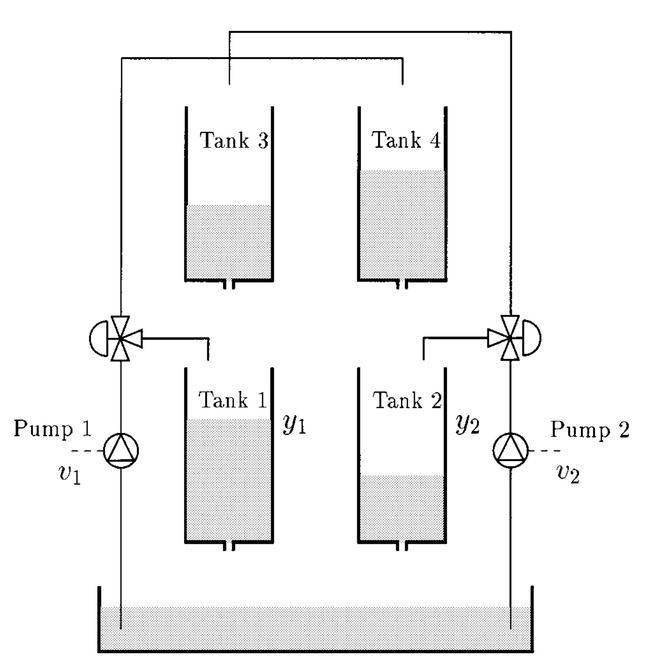

Let us consider the Quadruple-Tank Process. A schematic diagram of the process is shown in the Figure above. The
target is to control the level in the lower two tanks with two pumps. The process inputs are $v_1$ and $v_2$ (input voltages to the pumps) and the outputs are $y_1$ and $y_2$ (voltages from level measurement devices). Mass balances and Bernoulli’s law yield

$$
\dfrac{dh_1}{dt} = -\dfrac{a_1}{A_1}\sqrt{2gh_1} + \dfrac{a_3}{A_1}\sqrt{2gh_3} + \dfrac{\gamma_1k_1}{A_1}v_1 = f_1(h_1,h_2,h_3,h_4,v_1,v_2)
$$

$$
\dfrac{dh_2}{dt} = -\dfrac{a_2}{A_2}\sqrt{2gh_2} + \dfrac{a_4}{A_2}\sqrt{2gh_4} + \dfrac{\gamma_2k_2}{A_2}v_2 = f_2(h_1,h_2,h_3,h_4,v_1,v_2)
$$

$$
\dfrac{dh_3}{dt} = -\dfrac{a_3}{A_3}\sqrt{2gh_3} + \dfrac{(1-\gamma_2)k_2}{A_3}v_2 = f_3(h_1,h_2,h_3,h_4,v_1,v_2)
$$

$$
\dfrac{dh_4}{dt} = -\dfrac{a_4}{A_4}\sqrt{2gh_4} + \dfrac{(1-\gamma_1)k_1}{A_4}v_1 = f_4(h_1,h_2,h_3,h_4,v_1,v_2)
$$

where

$A_i$ is a cross-section of Tank i

$a_i$ is a cross-section of outlet hole of Tank i

$h_i$ is a water level.

The voltage applied to Pump $i$ is $v_i$ and the corresponding flow
is $k_iv_i$. The parameters $\gamma_1,\gamma_2\in (0,1)$ are determined from how the valves are set prior to experiment. The flow to Tank 1
is $\gamma_1k_1v_1$ and the flow to Tank 4 is $(1-\gamma_1)k_1v_1$ and similarly
for Tank 2 and Tank 3. The acceleration of gravity is denoted $g$.
The measured level signals are $k_c h_1$ and $k_c h_2$. The parameter
values of the laboratory process are given in the following table

    A_1, A_3 [cm^2] 28
    A_2, A_4 [cm^2] 32
    a_1, a_3 [cm^2] 0.071
    a_2, a_4 [cm^2] 0.057
    k_c [V/cm] 0.50
    g [cm/s^2] 9.81
    k_1 [cm^3/Vs] 3.33
    k_2 [cm^3/Vs] 3.35
    gamma_1 0.70
    gamma_2 0.60
    
Check the following paper for more details on the model. 
https://www.diva-portal.org/smash/get/diva2:495784/FULLTEXT01.pdf

## TODO
1. Linearise the system around the operating point 
$$(h_1^0,h_2^0,h_3^0,h_4^0, v_1^0, v_2^0) = (12.4,12.7,1.8,1.4,3.00,3.00).$$
Pass to shifted variables $x_i = h_i-h_i^0, u_i = v_i - v_i^0.$

2. Is the linear system controllable? Is the linear system observable? Use the Kalman rank test to answer this question.

3. Imagine that one of the pumps is broken and there is no flow through it. Does the system remain controllable?

4. Let us measure the signals $x_3, x_4$ instead of measuring the signals $x_1$ and $x_2,$ I .e matrix
   $$C= \begin{pmatrix} 0&0&1&0\\ 0&0&0&1 \end{pmatrix}$$
   instead of
   $$C= \begin{pmatrix} 1&0&0&0\\ 0&1&0&0 \end{pmatrix}.$$
 Is such a system observable?

### Answer TODO 1

Using the shifted variables $x_i = h_i - h_i^0$ and $u_i = v_i - v_i^0$, the linearized model around the operating point can be written as
$$\dot{x} = Ax + Bu, \quad y = Cx.$$
Using consistent centimeter units, $g = 981\,\mathrm{cm/s^2}$ was used. The linearized matrices are
$$A = \begin{pmatrix}-0.01595 & 0 & 0.04186 & 0\\ 0 & -0.01107 & 0 & 0.03334\\ 0 & 0 & -0.04186 & 0\\ 0 & 0 & 0 & -0.03334\end{pmatrix},$$
$$B = \begin{pmatrix}0.08325 & 0\\ 0 & 0.06281\\ 0 & 0.04786\\ 0.03122 & 0\end{pmatrix}.$$
If the measured outputs are the lower tank levels, then
$$C = \begin{pmatrix}0.5 & 0 & 0 & 0\\ 0 & 0.5 & 0 & 0\end{pmatrix}, \quad D = 0.$$
The residual at the operating point is very close to zero, so this point is an operating equilibrium up to rounding. The code used to compute these matrices is shown below.

In [7]:
import numpy as np

A1 = A3 = 28.0
A2 = A4 = 32.0
a1 = a3 = 0.071
a2 = a4 = 0.057
k_c = 0.50
g = 981.0
k1 = 3.33
k2 = 3.35
gamma1 = 0.70
gamma2 = 0.60

h0 = np.array([12.4, 12.7, 1.8, 1.4])
v0 = np.array([3.0, 3.0])

def flow_term(a, A, h):
    return a * g / (A * np.sqrt(2.0 * g * h))

A_lin = np.array([
    [-flow_term(a1, A1, h0[0]), 0.0, flow_term(a3, A1, h0[2]), 0.0],
    [0.0, -flow_term(a2, A2, h0[1]), 0.0, flow_term(a4, A2, h0[3])],
    [0.0, 0.0, -flow_term(a3, A3, h0[2]), 0.0],
    [0.0, 0.0, 0.0, -flow_term(a4, A4, h0[3])],
])

B_lin = np.array([
    [gamma1 * k1 / A1, 0.0],
    [0.0, gamma2 * k2 / A2],
    [0.0, (1.0 - gamma2) * k2 / A3],
    [(1.0 - gamma1) * k1 / A4, 0.0],
])

C_lin = np.array([
    [k_c, 0.0, 0.0, 0.0],
    [0.0, k_c, 0.0, 0.0],
])
D_lin = np.zeros((2, 2))

f0 = np.array([
    -(a1 / A1) * np.sqrt(2.0 * g * h0[0]) + (a3 / A1) * np.sqrt(2.0 * g * h0[2]) + (gamma1 * k1 / A1) * v0[0],
    -(a2 / A2) * np.sqrt(2.0 * g * h0[1]) + (a4 / A2) * np.sqrt(2.0 * g * h0[3]) + (gamma2 * k2 / A2) * v0[1],
    -(a3 / A3) * np.sqrt(2.0 * g * h0[2]) + ((1.0 - gamma2) * k2 / A3) * v0[1],
    -(a4 / A4) * np.sqrt(2.0 * g * h0[3]) + ((1.0 - gamma1) * k1 / A4) * v0[0],
])

np.set_printoptions(precision=8, suppress=True)
print("A =")
print(A_lin)
print()
print("B =")
print(B_lin)
print()
print("C =")
print(C_lin)
print()
print("D =")
print(D_lin)
print()
print("Residual at the operating point =")
print(f0)

A =
[[-0.0159481   0.          0.04185849  0.        ]
 [ 0.         -0.01106987  0.          0.03334113]
 [ 0.          0.         -0.04185849  0.        ]
 [ 0.          0.          0.         -0.03334113]]

B =
[[0.08325    0.        ]
 [0.         0.0628125 ]
 [0.         0.04785714]
 [0.03121875 0.        ]]

C =
[[0.5 0.  0.  0. ]
 [0.  0.5 0.  0. ]]

D =
[[0. 0.]
 [0. 0.]]

Residual at the operating point =
[ 0.00492766  0.00061798 -0.00711914  0.00030108]


### Answer TODO 2

Using the Kalman rank test, the linearized system is controllable and observable. The controllability matrix has rank $4$, which is equal to the number of states. The observability matrix also has rank $4$. Therefore, the linear model can be fully controlled from the two inputs and all states can be reconstructed from the measured outputs $y_1$ and $y_2$. The code used to compute these ranks is shown below.

In [8]:
import numpy as np

def controllability_matrix(A, B):
    n = A.shape[0]
    blocks = [B]
    for i in range(1, n):
        blocks.append(np.linalg.matrix_power(A, i) @ B)
    return np.hstack(blocks)

def observability_matrix(A, C):
    n = A.shape[0]
    blocks = [C]
    for i in range(1, n):
        blocks.append(C @ np.linalg.matrix_power(A, i))
    return np.vstack(blocks)

Wc = controllability_matrix(A_lin, B_lin)
Wo = observability_matrix(A_lin, C_lin)

rank_Wc = np.linalg.matrix_rank(Wc)
rank_Wo = np.linalg.matrix_rank(Wo)

print("Rank of controllability matrix:", rank_Wc)
print("Rank of observability matrix:", rank_Wo)

if rank_Wc == A_lin.shape[0]:
    print("The linearized system is controllable.")
else:
    print("The linearized system is not controllable.")

if rank_Wo == A_lin.shape[0]:
    print("The linearized system is observable.")
else:
    print("The linearized system is not observable.")

Rank of controllability matrix: 4
Rank of observability matrix: 4
The linearized system is controllable.
The linearized system is observable.


### Answer TODO 3

No, the system does not remain controllable if one pump is broken. If pump 1 is broken, the controllability matrix has rank $3$ instead of $4$. If pump 2 is broken, the controllability matrix also has rank $3$. Therefore, in both cases the linearized system loses controllability. This is consistent with the physical structure: when one pump is unavailable, one part of the process cannot be influenced anymore through the remaining input. The code used to check both cases is shown below.

In [9]:
import numpy as np

def controllability_matrix(A, B):
    n = A.shape[0]
    blocks = [B]
    for i in range(1, n):
        blocks.append(np.linalg.matrix_power(A, i) @ B)
    return np.hstack(blocks)

B_pump1_broken = B_lin[:, [1]]
B_pump2_broken = B_lin[:, [0]]

Wc_pump1_broken = controllability_matrix(A_lin, B_pump1_broken)
Wc_pump2_broken = controllability_matrix(A_lin, B_pump2_broken)

rank_pump1_broken = np.linalg.matrix_rank(Wc_pump1_broken)
rank_pump2_broken = np.linalg.matrix_rank(Wc_pump2_broken)

print("Rank with pump 1 broken:", rank_pump1_broken)
print("Rank with pump 2 broken:", rank_pump2_broken)

if rank_pump1_broken == A_lin.shape[0]:
    print("The system remains controllable when pump 1 is broken.")
else:
    print("The system is not controllable when pump 1 is broken.")

if rank_pump2_broken == A_lin.shape[0]:
    print("The system remains controllable when pump 2 is broken.")
else:
    print("The system is not controllable when pump 2 is broken.")

Rank with pump 1 broken: 3
Rank with pump 2 broken: 3
The system is not controllable when pump 1 is broken.
The system is not controllable when pump 2 is broken.


### Answer TODO 4

No, the system is not observable with this new output matrix. If we measure only $x_3$ and $x_4$, the observability matrix has rank $2$ instead of $4$. Therefore, the full state cannot be reconstructed from these measurements alone. In particular, the lower tank states $x_1$ and $x_2$ do not appear directly in the outputs, and the information provided by $x_3$ and $x_4$ is not sufficient to recover all four states. The code used to check this is shown below.

In [10]:
import numpy as np

def observability_matrix(A, C):
    n = A.shape[0]
    blocks = [C]
    for i in range(1, n):
        blocks.append(C @ np.linalg.matrix_power(A, i))
    return np.vstack(blocks)

C_alt = np.array([
    [0.0, 0.0, 1.0, 0.0],
    [0.0, 0.0, 0.0, 1.0],
])

Wo_alt = observability_matrix(A_lin, C_alt)
rank_Wo_alt = np.linalg.matrix_rank(Wo_alt)

print("Rank of observability matrix with alternative C:", rank_Wo_alt)

if rank_Wo_alt == A_lin.shape[0]:
    print("The system is observable with this output matrix.")
else:
    print("The system is not observable with this output matrix.")

Rank of observability matrix with alternative C: 2
The system is not observable with this output matrix.


## EX3: Inverted Pendulum

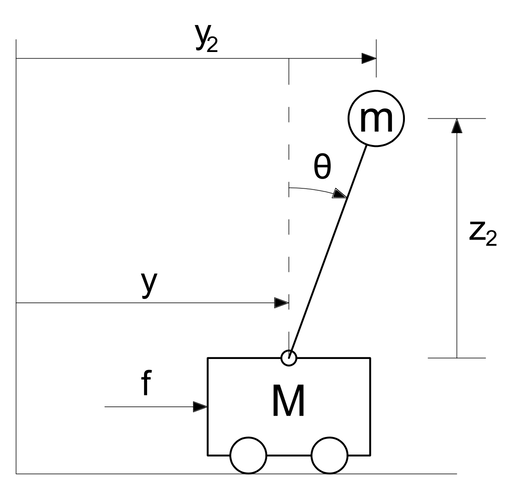
The system in this example consists of an inverted pendulum mounted to a motorized cart. The inverted pendulum system is an example commonly found in control system textbooks and research literature. Its popularity derives in part from the fact that it is unstable without control, that is, the pendulum will simply fall over if the cart isn't moved to balance it. Additionally, the dynamics of the system are nonlinear. The objective of the control system is to balance the inverted pendulum by applying a force to the cart that the pendulum is attached to. A real-world example that relates directly to this inverted pendulum system is the attitude control of a booster rocket at takeoff.
The system in this example consists of an inverted pendulum mounted to a motorized cart. The inverted pendulum system is an example commonly found in control system textbooks and research literature. Its popularity derives in part from the fact that it is unstable without control, that is, the pendulum will simply fall over if the cart isn't moved to balance it. Additionally, the dynamics of the system are nonlinear. The objective of the control system is to balance the inverted pendulum by applying a force to the cart that the pendulum is attached to. A real-world example that relates directly to this inverted pendulum system is the attitude control of a booster rocket at takeoff.


Let us consider the system with the following system parameters

    (M)       mass of the cart                         0.5 kg
    
    (m)       mass of the pendulum                     0.2 kg
    
    (l)       length to pendulum center of mass        0.3 m
    
    (b)       coefficient of friction for cart         0.1 N/m/sec
    
    (I)       mass moment of inertia of the pendulum   0.006 kg.m^2
    
    (F)       force applied to the cart
    
    (y)       cart position coordinate
    
    (theta)   angle between the pendulum and the vertical axis

## TODO

1) Show that the inverted pendulum on the cart can be modeled as follows

$$
(M+m)\ddot{y} + b\dot{y} + ml\ddot{\theta}\cos\theta -ml\dot\theta^2\sin(\theta) = F
$$

$$
ml\cos(\theta)\ddot{y} + (I+ml^2)\ddot{\theta} - mgl\sin\theta = 0
$$

2) Let the state vector $x = (y,y_1,\theta,\theta_1),$ where $y_1 = \dot{y}$ and $\theta_1 = \dot{\theta}.$ Lineralize the system around equlibrium  point $x = (0,0,0,0).$

3) Is the autonomous system stable (u = 0)? Is the system controllable? Design a full state feedback controller $u = -Kx$ assigning the following eigenvalues $\lambda_1 = - 1, \lambda_2 = -2, \lambda_3 = -1.5, \lambda_4 = -2.5$ in the closed-loop system. Is a closed-loop system stable?

4) Let us assume that we only measure the position $y$ and the angular velocitity $\theta$. What is the right matrix C? Is the system observable?

5) Design an optimal estimator and an optimal estimated-state-feedback controller (both via LQR design as discussed in the lecture) which stabilize the system in (0,0,0,0).

6) Use the following library to implement an MPC controller
    https://github.com/forgi86/pyMPC/blob/master/README.md
   that stabilize the system while ensuring that following state and input constraints are satisfied

   $x_{min} = [-5,-100,-100,-100]\leq x \leq x_{max}= [5,100,100,100]$
   
   $u_{min} = -20 \leq u\leq u_{max}=20$
   
   The following notebook can be useful for you 
   https://github.com/forgi86/pyMPC/blob/master/examples/example_inverted_pendulum.ipynb
   

### Answer TODO 1

Let the cart position be $y$ and the pendulum angle be $\theta$. The coordinates of the pendulum center of mass are taken as
$$x_p = y + l\sin\theta, \quad z_p = l\cos\theta.$$
By differentiating twice, the horizontal acceleration of the pendulum mass is
$$\ddot{x}_p = \ddot{y} + l\ddot{\theta}\cos\theta - l\dot{\theta}^2\sin\theta.$$
Applying Newton's second law in the horizontal direction to the cart-pendulum system gives
$$F - b\dot{y} = M\ddot{y} + m\ddot{x}_p.$$
Replacing $\ddot{x}_p$ gives
$$F - b\dot{y} = M\ddot{y} + m\left(\ddot{y} + l\ddot{\theta}\cos\theta - l\dot{\theta}^2\sin\theta\right),$$
which leads to
$$(M+m)\ddot{y} + b\dot{y} + ml\ddot{\theta}\cos\theta - ml\dot{\theta}^2\sin\theta = F.$$

For the pendulum rotation, taking moments about the pendulum center or using the Euler-Lagrange equation for $\theta$ gives
$$(I + ml^2)\ddot{\theta} = mgl\sin\theta - ml\cos\theta\,\ddot{y}.$$
Rearranging, we obtain
$$ml\cos\theta\,\ddot{y} + (I+ml^2)\ddot{\theta} - mgl\sin\theta = 0.$$
Therefore, the inverted pendulum on the cart can be modeled by the two equations required in the statement.

### Answer TODO 2

Let the state vector be $x = (y, y_1, \theta, \theta_1)$ with $y_1 = \dot y$ and $\theta_1 = \dot \theta$. Around the equilibrium point $(0,0,0,0)$, we use the approximations $\sin\theta \approx \theta$, $\cos\theta \approx 1$, and we neglect the nonlinear term $\dot\theta^2 \sin\theta$. Then the model becomes
$$(M+m)\ddot y + b\dot y + ml\ddot\theta = F,$$
$$ml\ddot y + (I+ml^2)\ddot\theta - mgl\theta = 0.$$
Solving these two equations for $\ddot y$ and $\ddot\theta$, the linearized state-space model is
$$\dot x = Ax + Bu,$$
with
$$A = \begin{pmatrix}0 & 1 & 0 & 0\\ 0 & -\dfrac{b(I+ml^2)}{p} & -\dfrac{m^2gl^2}{p} & 0\\ 0 & 0 & 0 & 1\\ 0 & \dfrac{mbl}{p} & \dfrac{(M+m)mgl}{p} & 0\end{pmatrix}, \quad B = \begin{pmatrix}0\\ \dfrac{I+ml^2}{p}\\ 0\\ -\dfrac{ml}{p}\end{pmatrix},$$
where
$$p = I(M+m) + Mml^2.$$
Using the numerical values from the statement, we obtain the matrices shown in the code cell below.

In [11]:
import numpy as np

M = 0.5
m = 0.2
l = 0.3
b = 0.1
I = 0.006
g = 9.8

p = I * (M + m) + M * m * l**2

A_lin_ip = np.array([
    [0.0, 1.0, 0.0, 0.0],
    [0.0, -b * (I + m * l**2) / p, -(m**2) * g * l**2 / p, 0.0],
    [0.0, 0.0, 0.0, 1.0],
    [0.0, m * l * b / p, (M + m) * m * g * l / p, 0.0],
])

B_lin_ip = np.array([
    [0.0],
    [(I + m * l**2) / p],
    [0.0],
    [-m * l / p],
])

np.set_printoptions(precision=8, suppress=True)
print("p =", p)
print()
print("A =")
print(A_lin_ip)
print()
print("B =")
print(B_lin_ip)

p = 0.0132

A =
[[ 0.          1.          0.          0.        ]
 [ 0.         -0.18181818 -2.67272727  0.        ]
 [ 0.          0.          0.          1.        ]
 [ 0.          0.45454545 31.18181818  0.        ]]

B =
[[ 0.        ]
 [ 1.81818182]
 [ 0.        ]
 [-4.54545455]]


### Answer TODO 3

The autonomous linearized system is not stable, because the matrix $A$ has one positive eigenvalue. The system is controllable, since the controllability matrix has rank $4$. Therefore, it is possible to design a full-state feedback controller $u = -Kx$ that places the closed-loop poles at the required values.

Using pole placement with $\lambda_1 = -1$, $\lambda_2 = -2$, $\lambda_3 = -1.5$, and $\lambda_4 = -2.5$, we obtain
$$K = \begin{pmatrix}-0.1684 & -0.5321 & -10.8323 & -1.7129\end{pmatrix}.$$
With this gain, the closed-loop eigenvalues are exactly the assigned values, so the closed-loop system is asymptotically stable. The code and plots are shown below.

Open-loop eigenvalues:
[ 0.         -0.14283164 -5.60409413  5.56510758]

Rank of controllability matrix: 4

K =
[[ -0.16836735  -0.53214286 -10.83234694  -1.71285714]]

Closed-loop eigenvalues:
[-2.5 -2.  -1.5 -1. ]


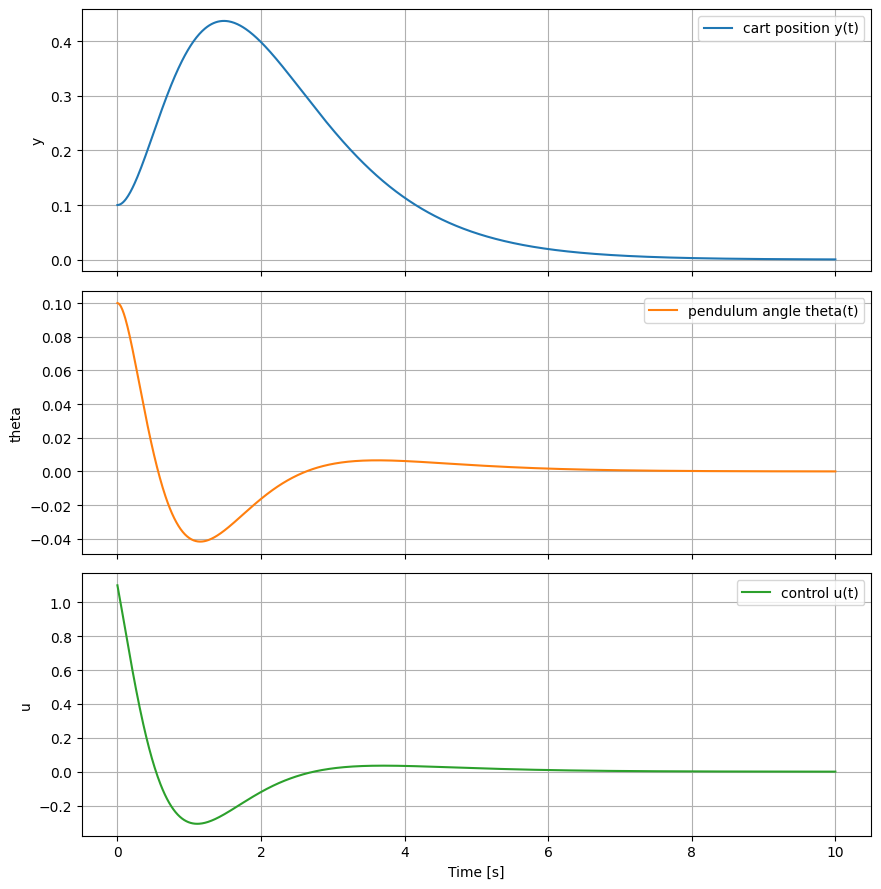

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import place_poles

def controllability_matrix(A, B):
    n = A.shape[0]
    blocks = [B]
    for i in range(1, n):
        blocks.append(np.linalg.matrix_power(A, i) @ B)
    return np.hstack(blocks)

Wc_ip = controllability_matrix(A_lin_ip, B_lin_ip)
rank_Wc_ip = np.linalg.matrix_rank(Wc_ip)
open_loop_eigs = np.linalg.eigvals(A_lin_ip)

desired_poles_ip = [-1.0, -2.0, -1.5, -2.5]
K_ip = place_poles(A_lin_ip, B_lin_ip, desired_poles_ip).gain_matrix
A_cl_ip = A_lin_ip - B_lin_ip @ K_ip
closed_loop_eigs = np.linalg.eigvals(A_cl_ip)

x0 = np.array([0.1, 0.0, 0.1, 0.0])
t_eval = np.linspace(0.0, 10.0, 1001)

def closed_loop_ip(t, x):
    u = float(-(K_ip @ x.reshape(-1, 1))[0, 0])
    return A_lin_ip @ x + B_lin_ip.flatten() * u

solution_ip = solve_ivp(closed_loop_ip, [t_eval[0], t_eval[-1]], x0, t_eval=t_eval)
x_ip = solution_ip.y
u_ip = -(K_ip @ x_ip).flatten()

print("Open-loop eigenvalues:")
print(open_loop_eigs)
print()
print("Rank of controllability matrix:", rank_Wc_ip)
print()
print("K =")
print(K_ip)
print()
print("Closed-loop eigenvalues:")
print(closed_loop_eigs)

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

axes[0].plot(t_eval, x_ip[0], label="cart position y(t)", color="tab:blue")
axes[0].grid(True)
axes[0].legend()
axes[0].set_ylabel("y")

axes[1].plot(t_eval, x_ip[2], label="pendulum angle theta(t)", color="tab:orange")
axes[1].grid(True)
axes[1].legend()
axes[1].set_ylabel("theta")

axes[2].plot(t_eval, u_ip, label="control u(t)", color="tab:green")
axes[2].grid(True)
axes[2].legend()
axes[2].set_ylabel("u")
axes[2].set_xlabel("Time [s]")

plt.tight_layout()
plt.show()

### Answer TODO 4

Yes, the system is observable. If the measured outputs are the cart position $y$ and the angular velocity $\dot{\theta}$, then the correct output matrix is
$$C = \begin{pmatrix}1 & 0 & 0 & 0\\ 0 & 0 & 0 & 1\end{pmatrix}.$$
For this choice, the observability matrix has rank $4$, which is equal to the number of states. Therefore, the linearized system is observable, and the full state can be reconstructed from the measurements of $y$ and $\dot{\theta}$. The code used to check this is shown below.

In [15]:
import numpy as np

def observability_matrix(A, C):
    n = A.shape[0]
    blocks = [C]
    for i in range(1, n):
        blocks.append(C @ np.linalg.matrix_power(A, i))
    return np.vstack(blocks)

C_ip = np.array([
    [1.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 1.0],
])

Wo_ip = observability_matrix(A_lin_ip, C_ip)
rank_Wo_ip = np.linalg.matrix_rank(Wo_ip)

print("C =")
print(C_ip)
print()
print("Rank of observability matrix:", rank_Wo_ip)

if rank_Wo_ip == A_lin_ip.shape[0]:
    print("The system is observable.")
else:
    print("The system is not observable.")

C =
[[1. 0. 0. 0.]
 [0. 0. 0. 1.]]

Rank of observability matrix: 4
The system is observable.


### Answer TODO 5

An optimal estimated-state-feedback controller can be built by combining an LQR state-feedback law with an observer designed by the dual LQR method. To stay consistent with TODO 4, the measured outputs are the cart position $y$ and the angular velocity $\dot{\theta}$.

The output matrix is
$$
C = \begin{pmatrix}1 & 0 & 0 & 0\\ 0 & 0 & 0 & 1\end{pmatrix}.
$$

For the state-feedback design, we choose
$$
Q = \operatorname{diag}(10,1,100,1), \quad R = 1.
$$

This gives
$$
K = \begin{pmatrix}-3.1623 & -3.9775 & -28.5922 & -5.1822\end{pmatrix}.
$$

For the estimator, using the dual problem with
$$
W = \operatorname{diag}(1,1,10,10), \quad V = \operatorname{diag}(0.1,0.1),
$$

we obtain
$$
L = \begin{pmatrix}3.9366 & -0.1072\\ 2.7541 & -2.3647\\ -0.0743 & 11.0496\\ -0.1072 & 28.0523\end{pmatrix}.
$$

With the controller $u = -K\hat{x}$ and the observer $\dot{\hat{x}} = A\hat{x} + Bu + L(y - C\hat{x})$, the plant state and the estimated state converge to the origin. Therefore, the observer-based optimal controller stabilizes the system using the same measurements considered in TODO 4. The code and plots are shown below.

C =
[[1. 0. 0. 0.]
 [0. 0. 0. 1.]]

K =
[[ -3.16227766  -3.97752221 -28.59223925  -5.18221039]]

Closed-loop eigenvalues:
[-7.02750772+2.58738246j -7.02750772-2.58738246j -1.22522299+1.0053208j
 -1.22522299-1.0053208j ]

L =
[[ 3.93658852 -0.10719552]
 [ 2.75411003 -2.36472445]
 [-0.07428079 11.0496011 ]
 [-0.10719552 28.05230944]]

Observer eigenvalues:
[ -2.96326169 +0.j         -1.11611755 +0.j
 -14.04566845+10.7747749j -14.04566845-10.7747749j]


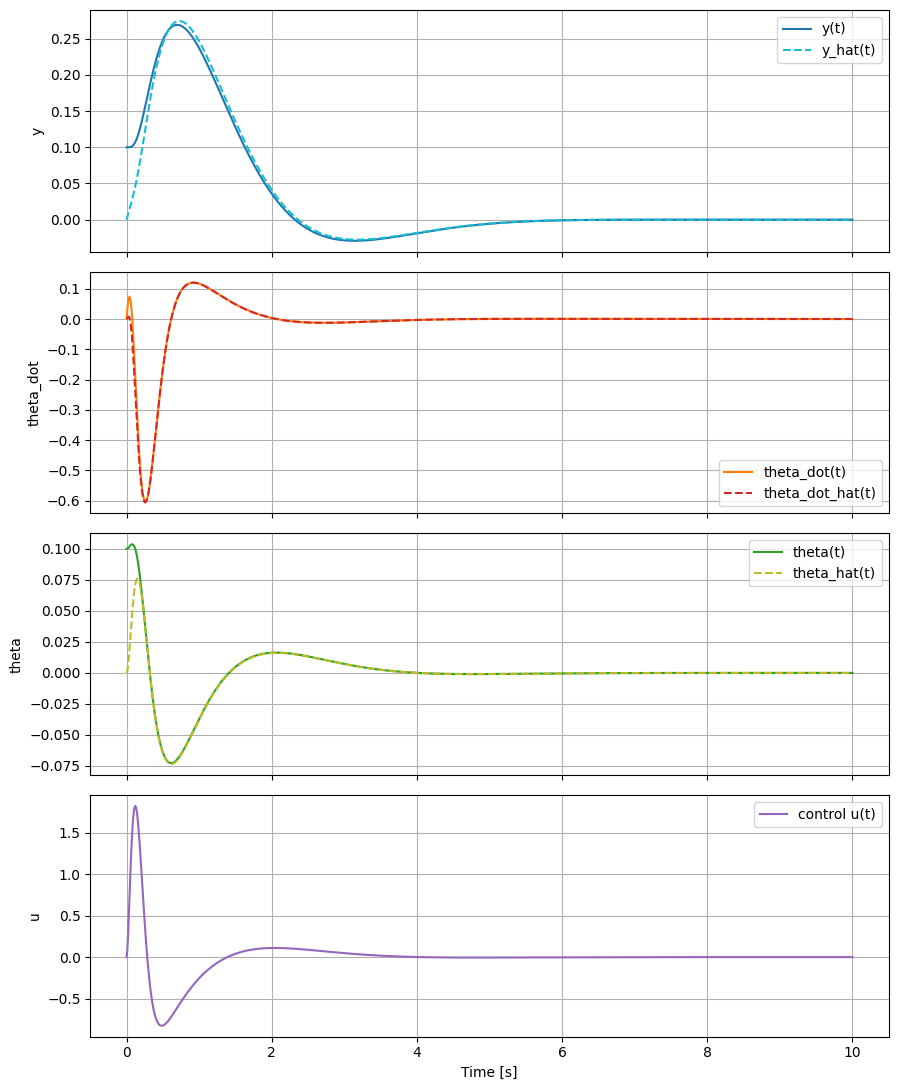

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import solve_continuous_are

M = 0.5
m = 0.2
l = 0.3
b = 0.1
I = 0.006
g = 9.8

p = I * (M + m) + M * m * l**2
A_lin_ip = np.array([
    [0.0, 1.0, 0.0, 0.0],
    [0.0, -b * (I + m * l**2) / p, -(m**2) * g * l**2 / p, 0.0],
    [0.0, 0.0, 0.0, 1.0],
    [0.0, m * l * b / p, (M + m) * m * g * l / p, 0.0],
])
B_lin_ip = np.array([
    [0.0],
    [(I + m * l**2) / p],
    [0.0],
    [-m * l / p],
])

Q_lqr = np.diag([10.0, 1.0, 100.0, 1.0])
R_lqr = np.array([[1.0]])

P_lqr = solve_continuous_are(A_lin_ip, B_lin_ip, Q_lqr, R_lqr)
K_lqr = np.linalg.solve(R_lqr, B_lin_ip.T @ P_lqr)

C_meas = np.array([
    [1.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 1.0],
])

W_est = np.diag([1.0, 1.0, 10.0, 10.0])
V_est = np.diag([0.1, 0.1])

P_est = solve_continuous_are(A_lin_ip.T, C_meas.T, W_est, V_est)
L_lqr = P_est @ C_meas.T @ np.linalg.inv(V_est)

closed_loop_eigs_lqr = np.linalg.eigvals(A_lin_ip - B_lin_ip @ K_lqr)
observer_eigs_lqr = np.linalg.eigvals(A_lin_ip - L_lqr @ C_meas)

t_eval = np.linspace(0.0, 10.0, 1001)
z0 = np.array([0.1, 0.0, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0])

def observer_based_system(t, z):
    x = z[:4]
    x_hat = z[4:]
    y = C_meas @ x
    u = float(-(K_lqr @ x_hat.reshape(-1, 1))[0, 0])
    dx = A_lin_ip @ x + B_lin_ip.flatten() * u
    dx_hat = A_lin_ip @ x_hat + B_lin_ip.flatten() * u + L_lqr @ (y - C_meas @ x_hat)
    return np.concatenate([dx, dx_hat])

solution_lqr = solve_ivp(observer_based_system, [t_eval[0], t_eval[-1]], z0, t_eval=t_eval)
x_lqr = solution_lqr.y[:4]
xhat_lqr = solution_lqr.y[4:]
u_lqr = -(K_lqr @ xhat_lqr).flatten()

print("C =")
print(C_meas)
print()
print("K =")
print(K_lqr)
print()
print("Closed-loop eigenvalues:")
print(closed_loop_eigs_lqr)
print()
print("L =")
print(L_lqr)
print()
print("Observer eigenvalues:")
print(observer_eigs_lqr)

fig, axes = plt.subplots(4, 1, figsize=(9, 11), sharex=True)

axes[0].plot(t_eval, x_lqr[0], label="y(t)", color="tab:blue")
axes[0].plot(t_eval, xhat_lqr[0], "--", label="y_hat(t)", color="tab:cyan")
axes[0].grid(True)
axes[0].legend()
axes[0].set_ylabel("y")

axes[1].plot(t_eval, x_lqr[3], label="theta_dot(t)", color="tab:orange")
axes[1].plot(t_eval, xhat_lqr[3], "--", label="theta_dot_hat(t)", color="tab:red")
axes[1].grid(True)
axes[1].legend()
axes[1].set_ylabel("theta_dot")

axes[2].plot(t_eval, x_lqr[2], label="theta(t)", color="tab:green")
axes[2].plot(t_eval, xhat_lqr[2], "--", label="theta_hat(t)", color="tab:olive")
axes[2].grid(True)
axes[2].legend()
axes[2].set_ylabel("theta")

axes[3].plot(t_eval, u_lqr, label="control u(t)", color="tab:purple")
axes[3].grid(True)
axes[3].legend()
axes[3].set_ylabel("u")
axes[3].set_xlabel("Time [s]")

plt.tight_layout()
plt.show()

### Answer TODO 6

An MPC controller was implemented with the pyMPC library for the discrete-time linearized model of the inverted pendulum. The sampling time was chosen as $T_s = 0.02\,s$, with prediction horizon $N_p = 60$ and control horizon $N_c = 12$.

The state constraints were
$$
x_{\min} = [-5,-100,-100,-100], \quad x_{\max} = [5,100,100,100].
$$

The input was limited to the interval $[-20, 20]$.

Starting from $x(0) = (0.1, 0, 0.1, 0)$, the controller stabilizes the system at the origin. During the simulation, the state constraints were satisfied and the input constraint was also satisfied. The maximum control value was about $2.88$, which is well inside the allowed interval. The code and plots are shown below.

Prediction horizon Np = 60, control horizon Nc = 12
Final state: [-2.08664339e-05  1.54571160e-04 -1.94856006e-05 -2.02490101e-06]
Maximum |u| during the simulation: 2.879
All state constraints satisfied: True
All input constraints satisfied: True
OSQP solved all MPC problems: True


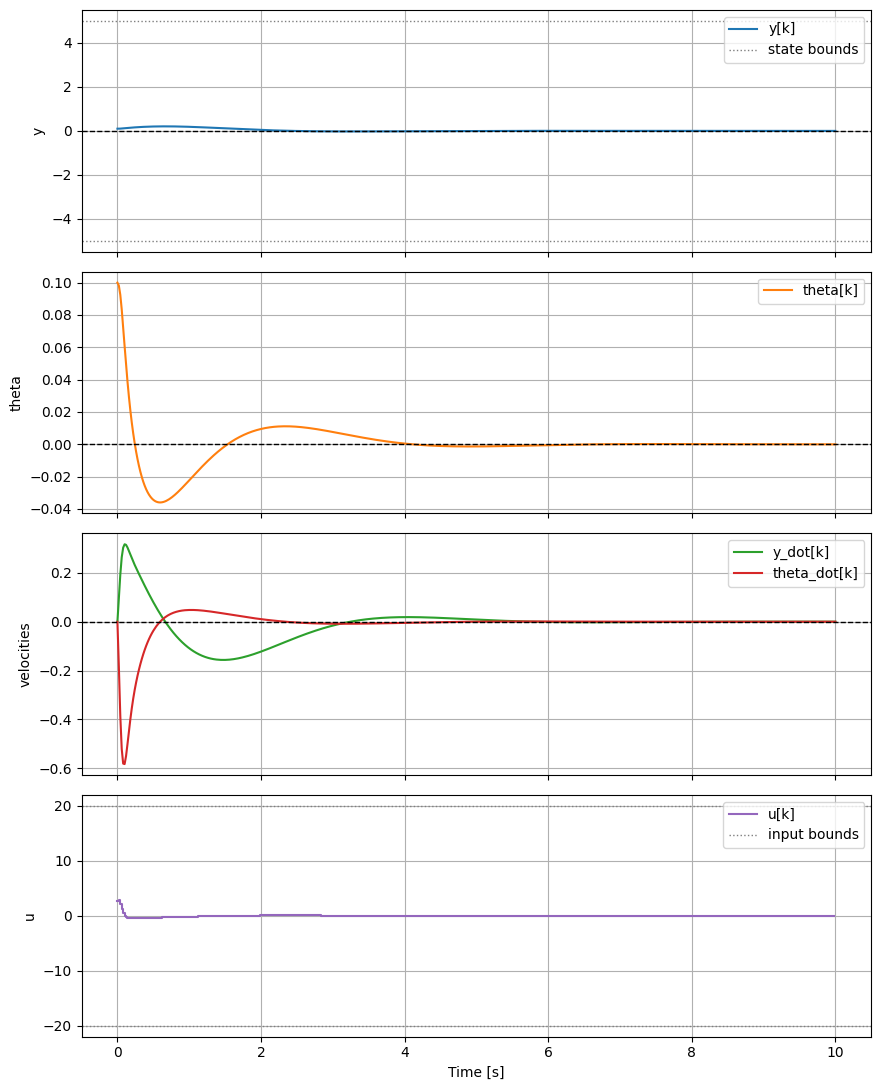

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import cont2discrete
from pyMPC.mpc import MPCController

M = 0.5
m = 0.2
l = 0.3
b = 0.1
I = 0.006
g = 9.8

p = I * (M + m) + M * m * l**2
A_lin_ip = np.array([
    [0.0, 1.0, 0.0, 0.0],
    [0.0, -b * (I + m * l**2) / p, -(m**2) * g * l**2 / p, 0.0],
    [0.0, 0.0, 0.0, 1.0],
    [0.0, m * l * b / p, (M + m) * m * g * l / p, 0.0],
])
B_lin_ip = np.array([
    [0.0],
    [(I + m * l**2) / p],
    [0.0],
    [-m * l / p],
])

Ts = 0.02
Ad, Bd, _, _, _ = cont2discrete((A_lin_ip, B_lin_ip, np.eye(4), np.zeros((4, 1))), Ts)

x_min = np.array([-5.0, -100.0, -100.0, -100.0])
x_max = np.array([5.0, 100.0, 100.0, 100.0])
u_min = np.array([-20.0])
u_max = np.array([20.0])

Qx_mpc = np.diag([30.0, 2.0, 400.0, 20.0])
QxN_mpc = np.diag([30.0, 2.0, 400.0, 20.0])
Qu_mpc = np.diag([0.1])
QDu_mpc = np.diag([0.8])

x0 = np.array([0.1, 0.0, 0.1, 0.0])
controller = MPCController(
    Ad,
    Bd,
    Np=60,
    Nc=12,
    x0=x0,
    xref=np.zeros(4),
    uref=np.zeros(1),
    uminus1=np.zeros(1),
    Qx=Qx_mpc,
    QxN=QxN_mpc,
    Qu=Qu_mpc,
    QDu=QDu_mpc,
    xmin=x_min,
    xmax=x_max,
    umin=u_min,
    umax=u_max,
    Dumin=np.array([-5.0]),
    Dumax=np.array([5.0]),
)
controller.setup()

Nsim = 500
time = np.arange(Nsim + 1) * Ts
x = x0.copy()
x_hist = [x.copy()]
u_hist = []
status_hist = []

for _ in range(Nsim):
    u_mpc, info = controller.output(return_status=True)
    u_mpc = np.asarray(u_mpc).reshape(-1)
    u_hist.append(u_mpc[0])
    status_hist.append(info["status"])

    x = Ad @ x + Bd @ u_mpc
    x_hist.append(x.copy())
    controller.update(x, u_mpc)

x_hist = np.array(x_hist)
u_hist = np.array(u_hist)

state_constraints_ok = np.all(x_hist >= x_min - 1e-9) and np.all(x_hist <= x_max + 1e-9)
input_constraints_ok = np.all(u_hist >= u_min[0] - 1e-9) and np.all(u_hist <= u_max[0] + 1e-9)
all_status_ok = all(status == "solved" for status in status_hist)

print(f"Prediction horizon Np = 60, control horizon Nc = 12")
print(f"Final state: {x_hist[-1]}")
print(f"Maximum |u| during the simulation: {np.max(np.abs(u_hist)):.3f}")
print(f"All state constraints satisfied: {state_constraints_ok}")
print(f"All input constraints satisfied: {input_constraints_ok}")
print(f"OSQP solved all MPC problems: {all_status_ok}")

fig, axes = plt.subplots(4, 1, figsize=(9, 11), sharex=True)

axes[0].plot(time, x_hist[:, 0], color="tab:blue", label="y[k]")
axes[0].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[0].axhline(x_max[0], color="tab:gray", linestyle=":", linewidth=1, label="state bounds")
axes[0].axhline(x_min[0], color="tab:gray", linestyle=":", linewidth=1)
axes[0].set_ylabel("y")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(time, x_hist[:, 2], color="tab:orange", label="theta[k]")
axes[1].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[1].set_ylabel("theta")
axes[1].grid(True)
axes[1].legend()

axes[2].plot(time, x_hist[:, 1], color="tab:green", label="y_dot[k]")
axes[2].plot(time, x_hist[:, 3], color="tab:red", label="theta_dot[k]")
axes[2].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[2].set_ylabel("velocities")
axes[2].grid(True)
axes[2].legend()

axes[3].step(time[:-1], u_hist, where="post", color="tab:purple", label="u[k]")
axes[3].axhline(u_max[0], color="tab:gray", linestyle=":", linewidth=1, label="input bounds")
axes[3].axhline(u_min[0], color="tab:gray", linestyle=":", linewidth=1)
axes[3].set_ylabel("u")
axes[3].set_xlabel("Time [s]")
axes[3].grid(True)
axes[3].legend()

plt.tight_layout()
plt.show()